In [ ]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

from catboost import CatBoostRegressor

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [2]:
#%pip cache purge
#%pip uninstall torch torchvision torchaudio -y
#%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

считывание данных из `C:\Users\limon\OneDrive\Рабочий стол\Курсовая\abob_progs\ANN\DATA`

# Data collection

In [ ]:
def load_data(ordinary_data, dir, data):
    path = f"{ordinary_data}/{dir}/{data}"
    with open(path, 'r', encoding='utf-8') as file:
        lines = file.readlines()[1:]  # Skip the first line (header)
    data_list = []
    for line in lines:
        values = list(map(float, line.split()))
        data_list.append(values)
    return data_list


def go_all_data(ordinary_data, dirs, nu_e_data):
    all_data = []
    for dir in dirs:
        data = load_data(ordinary_data, dir, nu_e_data)
        all_data.extend(data)
    return all_data



In [ ]:
ordinary_data = "C:/Users/limon/OneDrive/Рабочий стол/Курсовая/abob_progs/ANN/DATA"

first_day = 12
last_day  =  17

dirs = [f"{day}-04-2026" for day in range(first_day, last_day + 1)]

nu_e_data = "fort.31"
forces_data = "fort.42"

In [ ]:
X_data = go_all_data(ordinary_data, dirs, nu_e_data)
X_data = np.array(X_data)

Y_data = go_all_data(ordinary_data, dirs, forces_data)
Y_data = np.array(Y_data)


X_train, X_val_test, Y_train, Y_val_test = train_test_split(X_data, Y_data, test_size=0.2, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_val_test, Y_val_test, test_size=0.5, random_state=42)

In [ ]:
def average_absolute_percentage_error(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)))

def average_squared_percentage_error(y_true, y_pred):
    #return (np.sum((y_true - y_pred) ** 2) / np.sum(y_true ** 2 )) ** 0.5
    return np.mean(np.sum((y_true - y_pred) ** 2, axis=1) / np.sum(y_true ** 2, axis=1)) ** 0.5

# PCA

Из прошлых работ известно, что с помощью *PCA* можно сжать векторы усилий

In [6]:
# PCA for train, val, test
def make_pca(n_components, Y_train, Y_val, Y_test):
    pca = PCA(n_components=n_components)

    Y_train_pca = pca.fit_transform(Y_train)
    Y_val_pca = pca.transform(Y_val)
    Y_test_pca = pca.transform(Y_test)

    return Y_train_pca, Y_val_pca, Y_test_pca, pca

# check PCA for different n_components and print metrics
def check_pca(n_components_list, Y_train, Y_val, Y_test):
    for n_components in n_components_list:
        
        Y_train_pca, Y_val_pca, Y_test_pca, pca = make_pca(n_components, Y_train, Y_val, Y_test)

        print(f"NUMBER OF COMPONENTS: {n_components} is done.")

        # Восстановление данных
        Y_train_reconstructed = pca.inverse_transform(Y_train_pca)
        Y_val_reconstructed = pca.inverse_transform(Y_val_pca)
        Y_test_reconstructed = pca.inverse_transform(Y_test_pca)

        # Метрики для train
        mse_train = mean_squared_error(Y_train, Y_train_reconstructed)
        mae_train = mean_absolute_error(Y_train, Y_train_reconstructed)
        r2_train = r2_score(Y_train, Y_train_reconstructed)

        print(f"\nTrain Reconstruction - MSE: {mse_train:.2e}, MAE: {mae_train:.2e}, R²: {r2_train:.4f}")

        # Метрики для val
        mse_val = mean_squared_error(Y_val, Y_val_reconstructed)
        mae_val = mean_absolute_error(Y_val, Y_val_reconstructed)
        r2_val = r2_score(Y_val, Y_val_reconstructed)

        print(f"Val Reconstruction - MSE: {mse_val:.2e}, MAE: {mae_val:.2e}, R²: {r2_val:.4f}")

        # Метрики для test
        mse_test = mean_squared_error(Y_test, Y_test_reconstructed)
        mae_test = mean_absolute_error(Y_test, Y_test_reconstructed)
        r2_test = r2_score(Y_test, Y_test_reconstructed)

        print(f"Test Reconstruction - MSE: {mse_test:.2e}, MAE: {mae_test:.2e}, R²: {r2_test:.4f}")

        print(f"Train shape: {X_train.shape}, PCA shape: {Y_train_pca.shape}")
        print(f"Val shape: {X_val.shape}, PCA shape: {Y_val_pca.shape}")
        print(f"Test shape: {X_test.shape}, PCA shape: {Y_test_pca.shape}\n")
        print("-" * 50)


In [7]:
# В PCA надо подавать элменеты с матожиданием 0 и стандартным отклонением 1, поэтому стандартизируем данные перед PCA
y_scaler = StandardScaler()
Y_train_scaled = y_scaler.fit_transform(Y_train)
Y_val_scaled = y_scaler.transform(Y_val)
Y_test_scaled = y_scaler.transform(Y_test)

n_components_list = [i for i in range(1, Y_train.shape[1] + 1)]
check_pca(n_components_list, Y_train_scaled, Y_val_scaled, Y_test_scaled)

NUMBER OF COMPONENTS: 1 is done.

Train Reconstruction - MSE: 1.47e-01, MAE: 2.68e-01, R²: 0.8530
Val Reconstruction - MSE: 1.47e-01, MAE: 2.69e-01, R²: 0.8541
Test Reconstruction - MSE: 1.46e-01, MAE: 2.66e-01, R²: 0.8538
Train shape: (120826, 8), PCA shape: (120826, 1)
Val shape: (15103, 8), PCA shape: (15103, 1)
Test shape: (15104, 8), PCA shape: (15104, 1)

--------------------------------------------------
NUMBER OF COMPONENTS: 2 is done.

Train Reconstruction - MSE: 1.17e-02, MAE: 8.41e-02, R²: 0.9883
Val Reconstruction - MSE: 1.17e-02, MAE: 8.40e-02, R²: 0.9884
Test Reconstruction - MSE: 1.17e-02, MAE: 8.40e-02, R²: 0.9882
Train shape: (120826, 8), PCA shape: (120826, 2)
Val shape: (15103, 8), PCA shape: (15103, 2)
Test shape: (15104, 8), PCA shape: (15104, 2)

--------------------------------------------------
NUMBER OF COMPONENTS: 3 is done.

Train Reconstruction - MSE: 4.70e-03, MAE: 5.02e-02, R²: 0.9953
Val Reconstruction - MSE: 4.71e-03, MAE: 5.00e-02, R²: 0.9953
Test Recon

In [8]:
# В PCA надо подавать элменеты с матожиданием 0 и стандартным отклонением 1, поэтому стандартизируем данные перед PCA
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_val_scaled = x_scaler.transform(X_val)
X_test_scaled = x_scaler.transform(X_test)

n_components_list = [i for i in range(1, X_train.shape[1] + 1)]
check_pca(n_components_list, X_train_scaled, X_val_scaled, X_test_scaled)

NUMBER OF COMPONENTS: 1 is done.

Train Reconstruction - MSE: 8.18e-01, MAE: 7.53e-01, R²: 0.1820
Val Reconstruction - MSE: 8.18e-01, MAE: 7.53e-01, R²: 0.1840
Test Reconstruction - MSE: 8.22e-01, MAE: 7.55e-01, R²: 0.1800
Train shape: (120826, 8), PCA shape: (120826, 1)
Val shape: (15103, 8), PCA shape: (15103, 1)
Test shape: (15104, 8), PCA shape: (15104, 1)

--------------------------------------------------
NUMBER OF COMPONENTS: 2 is done.

Train Reconstruction - MSE: 6.95e-01, MAE: 6.82e-01, R²: 0.3045
Val Reconstruction - MSE: 6.98e-01, MAE: 6.85e-01, R²: 0.3033
Test Reconstruction - MSE: 6.99e-01, MAE: 6.84e-01, R²: 0.3015
Train shape: (120826, 8), PCA shape: (120826, 2)
Val shape: (15103, 8), PCA shape: (15103, 2)
Test shape: (15104, 8), PCA shape: (15104, 2)

--------------------------------------------------
NUMBER OF COMPONENTS: 3 is done.

Train Reconstruction - MSE: 5.74e-01, MAE: 6.07e-01, R²: 0.4264
Val Reconstruction - MSE: 5.78e-01, MAE: 6.11e-01, R²: 0.4229
Test Recon

In [9]:
Y_train_scaled, Y_val_scaled, Y_test_scaled


(array([[-2.77854943, -0.97291602,  2.12532398, ...,  1.98551886,
         -0.68113049, -2.48571407],
        [ 0.5529631 , -0.56451781,  0.10076354, ...,  0.22631419,
         -0.41300537,  0.12577434],
        [ 0.5529631 ,  0.95354064, -0.86214046, ..., -0.93791071,
          0.8409316 ,  0.740569  ],
        ...,
        [ 0.5529631 , -1.10159648,  0.2139947 , ...,  0.43956588,
         -1.23422826,  0.20277963],
        [ 0.5529631 ,  0.63696255, -0.72918521, ..., -0.78047414,
          0.42547266,  0.740569  ],
        [ 0.5529631 ,  1.35727166, -1.04766756, ..., -1.1316976 ,
          1.36270154,  0.740569  ]], shape=(120826, 8)),
 array([[ 0.5529631 ,  0.74031179, -0.71401345, ..., -0.78861635,
          0.56521225,  0.740569  ],
        [ 0.5529631 ,  1.51285788, -1.33107163, ..., -1.2962866 ,
          1.53051361,  0.740569  ],
        [-1.38283106, -0.87011518,  1.31510018, ...,  1.30221067,
         -0.60711749, -1.43660179],
        ...,
        [ 0.5529631 ,  0.89620582, 

In [10]:
# сжимаем до 4 компонент
n_components = 4
Y_train_pca, Y_val_pca, Y_test_pca, pca = make_pca(n_components, Y_train_scaled, Y_val_scaled, Y_test_scaled)
Y_train_pca, Y_val_pca, Y_test_pca

(array([[ 5.07544634, -1.93238237, -0.19278774,  0.12243386],
        [ 0.38332815,  0.82131476,  0.31960674, -0.13583701],
        [-2.39596179, -0.22265007, -0.07013043,  0.05232398],
        ...,
        [ 1.33995872,  1.60393295,  0.02234303, -0.13609528],
        [-1.82819461,  0.16246646, -0.1533094 ,  0.0635235 ],
        [-3.11691653, -0.7067095 ,  0.02583667,  0.02794798]],
       shape=(120826, 4)),
 array([[-1.99712731,  0.0173327 , -0.06495226,  0.10634846],
        [-3.43109958, -0.82065967, -0.13176089, -0.14012012],
        [ 3.23344746, -0.74854852,  0.04577558, -0.01222228],
        ...,
        [-2.24082449, -0.25426196,  0.189117  ,  0.27430311],
        [-0.91149665,  0.76612198, -0.25038461,  0.11131204],
        [ 1.53703736,  0.71730152,  0.29033218, -0.18420421]],
       shape=(15103, 4)),
 array([[ 0.2072378 ,  0.86691604,  0.1791162 , -0.10526942],
        [-0.37136447,  1.14830166, -0.35905175,  0.08538467],
        [ 0.87510769,  1.0399963 ,  0.25606787, -0.

In [11]:
#функция для обратного преобразования PCA
def inverse_pca(Y_pca, pca, scaler):
    Y_reconstructed = pca.inverse_transform(Y_pca)
    Y_reconstructed = scaler.inverse_transform(Y_reconstructed)
    return Y_reconstructed

Итоговые данные разобьем на DataLoaders

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

x_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(Y_train_pca, dtype=torch.float32)
x_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(Y_val_pca, dtype=torch.float32)
x_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(Y_test_pca, dtype=torch.float32)

train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

x_train_tensor.shape, y_train_tensor.shape

(torch.Size([120826, 8]), torch.Size([120826, 4]))

Пробую сначала построить необратимые нейронные сети

# $ (E, \nu) \to forces $

In [ ]:
class EnuToForces(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(EnuToForces, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim)
        )

    def forward(self, x):
        x = self.model(x)
        return x

In [ ]:
def train(model, 
          train_loader, 
          val_loader, 
          num_epochs, 
          learning_rate, 
          limit, 
          device='cpu', 
          history=None, 
          factor=0.5, 
          patience=7):
    
    criterion = nn.MSELoss()
    optimizer = Adam(model.parameters(), lr=learning_rate)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=factor, patience=patience)
     
    model.to(device)
    if history is None:
        history = {"train_loss": [], "val_loss": []}
    # train
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * x_batch.size(0)

        train_loss /= len(train_loader.dataset)

        # validate
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                outputs = model(x_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * x_batch.size(0)
        val_loss /= len(val_loader.dataset)
        scheduler.step(val_loss)
        # history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        # print metrics
        if epoch % limit == 0 or epoch == num_epochs - 1:
            print(f"Epoch {epoch }/{num_epochs}, Train Loss: {train_loss:.6e}, Val Loss: {val_loss:.6e}, LR: {optimizer.param_groups[0]['lr']:.6e}")
    return model, history, optimizer.param_groups[0]['lr']

In [ ]:
from pathlib import Path
from typing import Dict, Any, Optional

# функция для построения графиков истории обучения
def show_history(
    history,
    train_loss: str = "train_loss",
    val_loss: str = "val_loss",
    train_label: str = "Train Loss",
    val_label: str = "Val Loss",
    title: str = "Training and Validation Loss",
    save: bool = False,
    file_name: str = "history.png",
    path: str = "",
    ) -> None:
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history[train_loss], label=train_label)
    plt.plot(history[val_loss], label=val_label)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid()

    if save:
        # Создаем путь с помощью pathlib
        file_path = Path(path) / file_name if path else Path(file_name)
        
        # Создаем директорию, если она не существует
        file_path.parent.mkdir(parents=True, exist_ok=True)
        
        # Сохраняем файл
        plt.savefig(file_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {file_path.absolute()}")
    plt.show()


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
history = {"train_loss": [], "val_loss": []}
model = EnuToForces(input_dim=X_train.shape[1], output_dim=n_components)

In [56]:
model, history, _ = train(model, train_loader, val_loader, num_epochs=300, learning_rate=0.001, limit=10, device=device, history=history, factor=0.5, patience=5)

ModuleNotFoundError: No module named 'torch.fx.experimental.symbolic_shapes'

Plot saved to: C:\Users\limon\OneDrive\Рабочий стол\Курсовая\my_code\graphics\Enu-To-forces-history.png


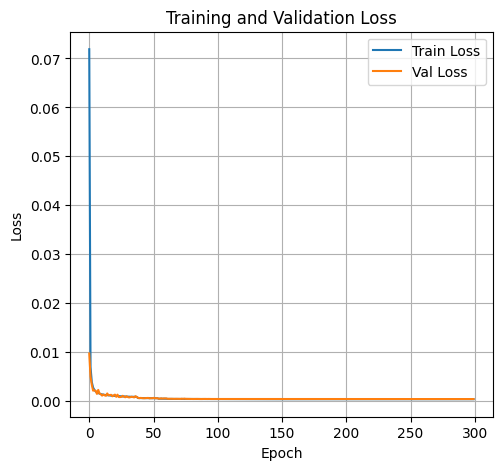

In [ ]:
show_history(history, save=True, file_name="Enu-To-forces-history.png", path="C:/Users/limon/OneDrive/Рабочий стол/Курсовая/my_code/graphics")

In [ ]:
# Проверка на тестовом наборе
model.eval()
test_loss = 0.0
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        outputs = model(x_batch)
        loss = F.mse_loss(outputs, y_batch)
        test_loss += loss.item() * x_batch.size(0)
test_loss /= len(test_loader.dataset)
print(f"Test Loss: {test_loss:.4e}")

Test Loss: 3.8609e-04


In [ ]:
# Пример предсказания на тестовом наборе
model.eval()
with torch.no_grad():
    # Сжатые данные
    x_sample, y_sample = next(iter(test_loader))
    output_sample = model(x_sample)
    # Восстанавливаем данные из PCA
    output_recovered = inverse_pca(output_sample.numpy(), pca, y_scaler)
    real_recovered = inverse_pca(y_sample.numpy(), pca, y_scaler)
    # Сравниваем предсказанные и реальные силы
    for i in range(2):
        print("Predicted PCA components:", output_sample[i])
        print("True PCA components:", y_sample[i])
        print("Predicted forces:", output_recovered[i])
        print("True forces:", real_recovered[i])
        print("\n")
    # mse, mae, r2 для восстановленных данных
    mse_test = mean_squared_error(real_recovered, output_recovered)
    mae_test = mean_absolute_error(real_recovered, output_recovered)
    r2_test = r2_score(real_recovered, output_recovered)
    avg_L1 = average_absolute_percentage_error(real_recovered, output_recovered)
    avg_L2 = average_squared_percentage_error(real_recovered, output_recovered)
    
    print("-" * 100)
    print(f"\nRecovered Test - MSE: {mse_test:.4e}, MAE: {mae_test:.4e}, R²: {r2_test:.4f}, L1: {avg_L1:.4e}, L2: {avg_L2:.4e}")


Predicted PCA components: tensor([ 0.2006,  0.8650,  0.1854, -0.0988])
True PCA components: tensor([ 0.2072,  0.8669,  0.1791, -0.1053])
Predicted forces: [ 1.00639934e-09 -5.18187140e-06 -8.71015775e-06 -1.02822181e-05
 -1.03914119e-05 -9.06101655e-06 -5.93120860e-06 -4.43122118e-07]
True forces: [-3.91931727e-10 -5.18524476e-06 -8.71239092e-06 -1.02763548e-05
 -1.03846082e-05 -9.06091127e-06 -5.93385646e-06 -4.46241719e-07]


Predicted PCA components: tensor([-0.3936,  1.1399, -0.3604,  0.0884])
True PCA components: tensor([-0.3714,  1.1483, -0.3591,  0.0854])
Predicted forces: [ 2.87715519e-09 -4.82418429e-06 -8.89444713e-06 -1.03517067e-05
 -1.04776418e-05 -9.34257732e-06 -6.11277154e-06  4.51606465e-10]
True forces: [ 2.62264883e-09 -4.83826709e-06 -8.89158272e-06 -1.03417924e-05
 -1.04670751e-05 -9.33745824e-06 -6.12212191e-06 -4.32519924e-09]


----------------------------------------------------------------------------------------------------

Recovered Test - MSE: 1.0314e-16, 

# $forces \to (E, \nu)$

In [ ]:
class ForcesToEnu(nn.Module):
    def __init__(self, input_dim, output_dim, layer_dims=[32, 64, 128, 64, 32], activation=nn.ReLU):
        super(ForcesToEnu, self).__init__()

        self.layers = [nn.Linear(input_dim, layer_dims[0]), activation()]
        for i in range(len(layer_dims) - 1):
            self.layers.append(nn.Linear(layer_dims[i], layer_dims[i + 1]))
            self.layers.append(activation())
        self.layers.append(nn.Linear(layer_dims[-1], output_dim))
        
        self.model = nn.Sequential(*self.layers)

    def forward(self, x):
        return self.model(x)

In [ ]:
#scaler = StandardScaler()
X_train_scaled = (X_train - 0.5 ) / 1.5
X_val_scaled = (X_val - 0.5 ) / 1.5
X_test_scaled = (X_test - 0.5 ) / 1.5

x_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(Y_train_pca, dtype=torch.float32)
#y_train_tensor = torch.tensor(Y_train_scaled, dtype=torch.float32)

x_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(Y_val_pca, dtype=torch.float32)
#y_val_tensor = torch.tensor(Y_val_scaled, dtype=torch.float32)

x_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(Y_test_pca, dtype=torch.float32)
#y_test_tensor = torch.tensor(Y_test_scaled, dtype=torch.float32)

train_rev_dataset = TensorDataset(y_train_tensor, x_train_tensor)
train_rev_loader = DataLoader(train_rev_dataset, batch_size=32, shuffle=True)
val_rev_dataset = TensorDataset(y_val_tensor, x_val_tensor)
val_rev_loader = DataLoader(val_rev_dataset, batch_size=32, shuffle=False)
test_rev_dataset = TensorDataset(y_test_tensor, x_test_tensor)
test_rev_loader = DataLoader(test_rev_dataset, batch_size=32, shuffle=False)

x_train_tensor.shape, y_train_tensor.shape

(torch.Size([87312, 8]), torch.Size([87312, 4]))

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [ ]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("GPU count:", torch.cuda.device_count())
    print("Current GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cpu
CUDA available: False


In [ ]:
model_rev = ForcesToEnu(input_dim=4, output_dim=X_train.shape[1], layer_dims=[32, 64, 128, 64, 32], activation=nn.GELU)
history_rev = {"train_loss": [], "val_loss": []}
lr = 1e-4
print(model_rev)

ForcesToEnu(
  (model): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=64, out_features=128, bias=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): GELU(approximate='none')
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): GELU(approximate='none')
    (10): Linear(in_features=32, out_features=8, bias=True)
  )
)


In [ ]:
for i in range(4):
    print(f"\nTraining iteration {i+1} with factor={0.5 + i * 0.1} and patience={5 + i * 10}, learning rate={lr * 10}")
    model_rev, history_rev, lr = train(model_rev, train_rev_loader, val_rev_loader, num_epochs=300, learning_rate=lr * 10, limit=10, device=device, history=history_rev,  factor=0.5 + i * 0.2, patience=7 + i * 5)



Training iteration 1 with factor=0.5 and patience=5, learning rate=0.001
Epoch 0/300, Train Loss: 3.990401e-02, Val Loss: 3.327494e-02, LR: 1.000000e-03
Epoch 10/300, Train Loss: 2.993594e-02, Val Loss: 2.884508e-02, LR: 1.000000e-03
Epoch 20/300, Train Loss: 2.752384e-02, Val Loss: 2.882871e-02, LR: 1.000000e-03
Epoch 30/300, Train Loss: 2.710029e-02, Val Loss: 2.965936e-02, LR: 1.000000e-03
Epoch 40/300, Train Loss: 2.576100e-02, Val Loss: 2.509980e-02, LR: 5.000000e-04
Epoch 50/300, Train Loss: 2.584611e-02, Val Loss: 2.486379e-02, LR: 5.000000e-04
Epoch 60/300, Train Loss: 2.571849e-02, Val Loss: 2.498032e-02, LR: 5.000000e-04
Epoch 70/300, Train Loss: 2.497606e-02, Val Loss: 2.501985e-02, LR: 2.500000e-04
Epoch 80/300, Train Loss: 2.488091e-02, Val Loss: 2.442910e-02, LR: 2.500000e-04
Epoch 90/300, Train Loss: 2.486146e-02, Val Loss: 2.496228e-02, LR: 1.250000e-04
Epoch 100/300, Train Loss: 2.443791e-02, Val Loss: 2.389667e-02, LR: 1.250000e-04
Epoch 110/300, Train Loss: 2.440362

KeyboardInterrupt: 

In [ ]:
# Проверка на тестовом наборе
model_rev.eval()
test_loss = 0.0
with torch.no_grad():
    for x_batch, y_batch in test_rev_loader:
        outputs = model_rev(x_batch)
        loss = F.mse_loss(outputs, y_batch)
        test_loss += loss.item() * x_batch.size(0)
test_loss /= len(test_rev_loader.dataset)
print(f"Test Loss: {test_loss:.4f}")

Test Loss: 0.0240


Plot saved to: C:\Users\limon\OneDrive\Рабочий стол\Курсовая\my_code\graphics\Forces-To-Enu-history.png


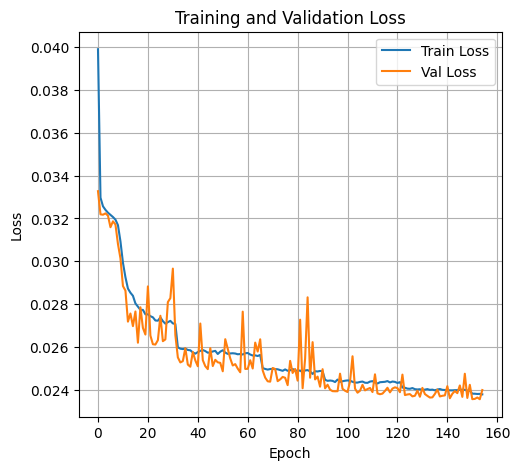

In [ ]:
show_history(history_rev, save=True, file_name="Forces-To-Enu-history.png", path="C:/Users/limon/OneDrive/Рабочий стол/Курсовая/my_code/graphics")

In [ ]:
# Пример предсказания на тестовом наборе
model.eval()
with torch.no_grad():
    # Сжатые данные
    x_sample, y_sample = next(iter(test_rev_loader))
    output_sample = model_rev(x_sample)
    # Восстанавливаем данные 
    output_recovered = output_sample.numpy() * 1.5 + 0.5
    real_recovered = y_sample.numpy() * 1.5 + 0.5
    # Сравниваем предсказанные и реальные силы
    for i in range(2):
        print("Predicted components:", output_sample[i])
        print("True components:", y_sample[i])
        print("Predicted enu:", output_recovered[i])
        print("True enu:", real_recovered[i])
        print("\n")
    # mse, mae, r2 для восстановленных данных
    mse_test = mean_squared_error(real_recovered, output_recovered)
    mae_test = mean_absolute_error(real_recovered, output_recovered)
    r2_test = r2_score(real_recovered, output_recovered)
    avg_L1 = average_absolute_percentage_error(real_recovered, output_recovered)
    avg_L2 = average_squared_percentage_error(real_recovered, output_recovered)
    
    print("-" * 100)
    print(f"\nRecovered Test - MSE: {mse_test:.4e}, MAE: {mae_test:.4e}, R²: {r2_test:.4f}, L1: {avg_L1:.4e}, L2: {avg_L2:.4e}")


Predicted components: tensor([ 0.4466, -0.1037,  0.4515, -0.1045,  0.0790, -0.1137,  0.1662, -0.1077])
True components: tensor([ 0.4585, -0.0637,  0.4503, -0.1305,  0.0178, -0.1618,  0.1314, -0.0567])
Predicted enu: [1.1699297  0.344472   1.1772723  0.3432929  0.6184443  0.32945195
 0.7492386  0.33838817]
True enu: [1.18775   0.4045176 1.175417  0.3042203 0.5267026 0.2573224 0.6971746
 0.414966 ]


Predicted components: tensor([ 0.6739, -0.1006,  0.7106, -0.1026,  0.6100, -0.0998,  0.5097, -0.1095])
True components: tensor([ 0.7346, -0.0563,  0.4915, -0.1032,  0.4988, -0.0814,  0.4331, -0.0479])
Predicted enu: [1.510814   0.3490491  1.5658832  0.3461541  1.414997   0.35024008
 1.2646214  0.33572888]
True enu: [1.601929   0.415544   1.237312   0.3451606  1.248265   0.37786752
 1.149642   0.428171  ]


----------------------------------------------------------------------------------------------------

Recovered Test - MSE: 4.9918e-02, MAE: 1.2975e-01, R²: 0.3386, L1: 1.5322e-01, L2: 2.0

# Try *Invertible* architecture

## Data collect

In [13]:
EPS = 1e-12

def enu_to_lame(X):
    """(E, nu) -> (lambda, mu). X shape: (N, 8) -> [lambda0, mu0, lambda1, mu1, ...]"""
    E = X[:, 0::2]
    nu = X[:, 1::2]
    
    # Защита от ν = -1 или ν = 0.5 (физически недопустимо, но бывает в шумных данных)
    nu_safe = np.clip(nu, -0.99, 0.49)
    
    mu = E / (2.0 * (1.0 + nu_safe))
    lam = (E * nu_safe) / ((1.0 + nu_safe) * (1.0 - 2.0 * nu_safe))
    
    X_lame = np.zeros_like(X)
    X_lame[:, 0::2] = lam
    X_lame[:, 1::2] = mu
    return X_lame

def lame_to_enu(X_lame):
    """(lsmbda, mu) -> (E, ν)"""
    lam = X_lame[:, 0::2]
    mu = X_lame[:, 1::2]
    
    denom = lam + mu + EPS
    E = mu * (3.0 * lam + 2.0 * mu) / denom
    nu = lam / (2.0 * denom)
    
    X_enu = np.zeros_like(X_lame)
    X_enu[:, 0::2] = E
    X_enu[:, 1::2] = nu
    return X_enu

In [14]:
#from sklearn.preprocessing import RobustScaler, MinMaxScaler
def make_datasets(X_train, Y_train, X_val, Y_val, X_test, Y_test, lame=False, bath_size=64):
    if lame:
        X_train = enu_to_lame(X_train)
        X_val   = enu_to_lame(X_val)
        X_test  = enu_to_lame(X_test)


    X_scaler_R = StandardScaler()
    Y_scaler_R = StandardScaler()  # устойчив к выбросам
    #MinMaxScaler(feature_range=(-1.5, 1.5))


    #X_scaler = StandardScaler()
    X_train_sc = X_scaler_R.fit_transform(X_train)
    X_val_sc   = X_scaler_R.transform(X_val)
    X_test_sc  = X_scaler_R.transform(X_test)

    #Y_scaler = StandardScaler()

    Y_train_sc = Y_scaler_R.fit_transform(Y_train)
    Y_val_sc   = Y_scaler_R.transform(Y_val)
    Y_test_sc  = Y_scaler_R.transform(Y_test)

    # 2. Тензоры и DataLoader
    train_dataset = TensorDataset(
        torch.tensor(X_train_sc, dtype=torch.float32),
        torch.tensor(Y_train_sc, dtype=torch.float32)
    )
    val_dataset = TensorDataset(
        torch.tensor(X_val_sc, dtype=torch.float32),
        torch.tensor(Y_val_sc, dtype=torch.float32)
    )

    train_loader = DataLoader(train_dataset, batch_size=bath_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=bath_size, shuffle=False)
    #X_train_sc.shape, X_val_sc.shape, X_test_sc.shape

    print(f"X_scaled range: [{X_train_sc.min():.3f}, {X_train_sc.max():.3f}]")
    print(f"Y_scaled range: [{Y_train_sc.min():.3f}, {Y_train_sc.max():.3f}]")
    print(f"X_scaled range: [{X_val_sc.min():.3f}, {X_val_sc.max():.3f}]")
    print(f"Y_scaled range: [{Y_val_sc.min():.3f}, {Y_val_sc.max():.3f}]")
    print(f"X_scaled range: [{X_test_sc.min():.3f}, {X_test_sc.max():.3f}]")
    print(f"Y_scaled range: [{Y_test_sc.min():.3f}, {Y_test_sc.max():.3f}]")
    return train_loader, val_loader, X_scaler_R, Y_scaler_R, X_test_sc, Y_test_sc


Invertible layers

## Архитектура

In [15]:
class InverseLayers(nn.Module):

    def __init__(self, input_dim, output_dim, hidden_dims=[64, 128, 64], activation=nn.GELU, bn_momentum=0.1, norm_layers=False):
        super(InverseLayers, self).__init__()
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            if norm_layers:
                layers.append(nn.BatchNorm1d(h_dim, momentum=bn_momentum, eps=1e-5))
            layers.append(activation()) 
            prev_dim = h_dim
        Last_layer = nn.Linear(prev_dim, output_dim)
        # Инициализация в ноль: на старте s=0, t=0 => exp(s)=1 => v=u
        nn.init.zeros_(Last_layer.weight)
        nn.init.zeros_(Last_layer.bias)
        layers.append(Last_layer)        
        self.net = nn.Sequential(*layers)


    def forward(self, x):
        return self.net(x)

\begin{align}
    v_1 &= (u_2 + t_1(u_1)) \cdot exp(s_1(u_1)) & 
    u_1 &= (v_2 / exp(s_2(v_1))) - t_2(v_1) \\
    v_2 &= (u_1 + t_2(v_1)) \cdot exp(s_2(v_1)) & 
    u_2 &= (v_1 / exp(s_1(u_1))) - t_1(u_1)x
\end{align}

In [ ]:
# Обратимая нейросеть для преобразования между Enu и Forces
class InverseEnuToForcesANN(nn.Module):
    def __init__(self, 
                 inp1_dim=4, 
                 inp2_dim=4, 
                 layer_s1_dims=[32, 16], 
                 layer_s2_dims=[32, 16], 
                 layer_t1_dims=[32, 16], 
                 layer_t2_dims=[32, 16], 
                 s1_activation=nn.ReLU,
                 s2_activation=nn.ReLU,
                 t1_activation=nn.ReLU,
                 t2_activation=nn.ReLU,
                 clamp_range=(-5.0, 1.0),
                 bn_momentum=0.1,
                 norm_layers=False
                 ):
        super(InverseEnuToForcesANN, self).__init__()
        self.clamp_range = clamp_range
        self.inp1_dim = inp1_dim
        self.inp2_dim = inp2_dim
        self.clamp = clamp_range[1]

        self.s1 = InverseLayers(input_dim=inp2_dim, output_dim=inp1_dim, hidden_dims=layer_s1_dims, activation=s1_activation, bn_momentum=bn_momentum, norm_layers=norm_layers)
        self.t1 = InverseLayers(input_dim=inp2_dim, output_dim=inp1_dim, hidden_dims=layer_t1_dims, activation=t1_activation, bn_momentum=bn_momentum, norm_layers=norm_layers)

        self.s2 = InverseLayers(input_dim=inp1_dim, output_dim=inp2_dim, hidden_dims=layer_s2_dims, activation=s2_activation, bn_momentum=bn_momentum, norm_layers=norm_layers)
        self.t2 = InverseLayers(input_dim=inp1_dim, output_dim=inp2_dim, hidden_dims=layer_t2_dims, activation=t2_activation, bn_momentum=bn_momentum, norm_layers=norm_layers)


    def _clamp(self, x):
        return torch.clamp(x, min=self.clamp_range[0], max=self.clamp_range[1])

    def forward(self, x, inverse=False):
        if not inverse:
            u1 = x[:, :self.inp1_dim]
            u2 = x[:, self.inp1_dim:]

            #s1 = self._clamp(self.s1(u2))
            s1 = self.clamp * torch.tanh(self.s1(u2))
            t1 = self.t1(u2)
            v1 = u1 * torch.exp(s1) + t1
            
            #s2 = self._clamp(self.s2(v1))
            s2 = self.clamp * torch.tanh(self.s2(v1))
            t2 = self.t2(v1)
            v2 = u2 * torch.exp(s2) + t2
            
            return torch.cat([v1, v2], dim=1)
        else:
            v1 = x[:, :self.inp1_dim]
            v2 = x[:, self.inp1_dim:]
            
            s2 = self.clamp * torch.tanh(self.s2(v1))
            #s2 = self._clamp(self.s2(v1))
            t2 = self.t2(v1)
            u2 = (v2 - t2) * torch.exp(-s2)
            
            s1 = self.clamp * torch.tanh(self.s1(u2))
            #s1 = self._clamp(self.s1(u2))
            t1 = self.t1(u2)
            u1 = (v1 - t1) * torch.exp(-s1)
            
            return torch.cat([u1, u2], dim=1)
        
# Архитектура многослойной обратимой сети
class MultiInvertibleANN(nn.Module):
    def __init__(
        self, 
        inp1_dim=4, 
        inp2_dim=4, 
        layer_s1_dims=[32, 16], 
        layer_s2_dims=[32, 16], 
        layer_t1_dims=[32, 16], 
        layer_t2_dims=[32, 16], 
        s1_activation=nn.ReLU,
        s2_activation=nn.ReLU,
        t1_activation=nn.ReLU,
        t2_activation=nn.ReLU,
        inv_layers=3,
        clamp_range=(-1.0, 1.0),
        bn_momentum=0.1,
        norm_layers=False,
    ):
        
        # Фиксированная случайная перестановка для каждого слоя
        self.permutations = []
        self.inv_permutations = []
        for _ in range(inv_layers):
            perm = torch.randperm(inp1_dim + inp2_dim)
            self.permutations.append(perm)
            self.inv_permutations.append(torch.argsort(perm))
        
        # Слои
        super(MultiInvertibleANN, self).__init__()
        self.inp1_dim = inp1_dim
        self.inp2_dim = inp2_dim
        self.layers = nn.ModuleList()
        for _ in range(inv_layers):
            self.layers.append(InverseEnuToForcesANN(
                inp1_dim=inp1_dim, 
                inp2_dim=inp2_dim, 
                layer_s1_dims=layer_s1_dims, 
                layer_s2_dims=layer_s2_dims, 
                layer_t1_dims=layer_t1_dims, 
                layer_t2_dims=layer_t2_dims, 
                s1_activation=s1_activation,
                s2_activation=s2_activation,
                t1_activation=t1_activation,
                t2_activation=t2_activation,
                clamp_range=clamp_range,
                bn_momentum=bn_momentum,
                norm_layers=norm_layers
            ))
            

    #def forward(self, x, inverse=False):
    #    if not inverse:
    #        for layer in self.layers:
    #            x = layer(x, inverse=False)
    #            x = self._permute(x)  #  Перемешивание между слоями
    #    else:
    #        #  Обратный проход  идёт в обратном порядке слоёв
    #        for layer in reversed(self.layers):
    #            x = self._permute(x)  # Обратное перемешивание
    #            x = layer(x, inverse=True)
    #    return x

    #def _permute(self, x):
    #    # Меняем местами части вектора, чтобы в следующем слое 
    #    # пассивные признаки стали активными и наоборот.
    #    return torch.cat([x[:, self.inp1_dim:], x[:, :self.inp1_dim]], dim=1)
    
    def _permute(self, x, layer_idx):
        """Прямая перестановка для слоя layer_idx"""
        perm = self.permutations[layer_idx].to(x.device)
        return x[:, perm]
    
    def _permute_inv(self, x, layer_idx):
        """Обратная перестановка для слоя layer_idx"""
        inv_perm = self.inv_permutations[layer_idx].to(x.device)
        return x[:, inv_perm]

    def forward(self, x, inverse=False):
        if not inverse:
            for idx, layer in enumerate(self.layers):
                x = layer(x, inverse=False)
                x = self._permute(x, idx)  # ← применяем перестановку слоя
        else:
            for idx in reversed(range(len(self.layers))):
                x = self._permute_inv(x, idx)  # ← обратная перестановка
                x = self.layers[idx](x, inverse=True)
        return x

In [17]:
model_inv = InverseEnuToForcesANN()
model_inv

InverseEnuToForcesANN(
  (s1): InverseLayers(
    (net): Sequential(
      (0): Linear(in_features=4, out_features=32, bias=True)
      (1): ReLU()
      (2): Linear(in_features=32, out_features=16, bias=True)
      (3): ReLU()
      (4): Linear(in_features=16, out_features=4, bias=True)
    )
  )
  (t1): InverseLayers(
    (net): Sequential(
      (0): Linear(in_features=4, out_features=32, bias=True)
      (1): ReLU()
      (2): Linear(in_features=32, out_features=16, bias=True)
      (3): ReLU()
      (4): Linear(in_features=16, out_features=4, bias=True)
    )
  )
  (s2): InverseLayers(
    (net): Sequential(
      (0): Linear(in_features=4, out_features=32, bias=True)
      (1): ReLU()
      (2): Linear(in_features=32, out_features=16, bias=True)
      (3): ReLU()
      (4): Linear(in_features=16, out_features=4, bias=True)
    )
  )
  (t2): InverseLayers(
    (net): Sequential(
      (0): Linear(in_features=4, out_features=32, bias=True)
      (1): ReLU()
      (2): Linear(in_fea

In [18]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_multi = MultiInvertibleANN(inv_layers=3).to(device)
model_multi

MultiInvertibleANN(
  (layers): ModuleList(
    (0-2): 3 x InverseEnuToForcesANN(
      (s1): InverseLayers(
        (net): Sequential(
          (0): Linear(in_features=4, out_features=32, bias=True)
          (1): ReLU()
          (2): Linear(in_features=32, out_features=16, bias=True)
          (3): ReLU()
          (4): Linear(in_features=16, out_features=4, bias=True)
        )
      )
      (t1): InverseLayers(
        (net): Sequential(
          (0): Linear(in_features=4, out_features=32, bias=True)
          (1): ReLU()
          (2): Linear(in_features=32, out_features=16, bias=True)
          (3): ReLU()
          (4): Linear(in_features=16, out_features=4, bias=True)
        )
      )
      (s2): InverseLayers(
        (net): Sequential(
          (0): Linear(in_features=4, out_features=32, bias=True)
          (1): ReLU()
          (2): Linear(in_features=32, out_features=16, bias=True)
          (3): ReLU()
          (4): Linear(in_features=16, out_features=4, bias=True)


In [19]:
pred = model_multi(torch.tensor(X_train_sc[0:1], dtype=torch.float32).to(device), inverse=False)
pred,  model_multi(pred, inverse=True), X_train_sc[0:1]

NameError: name 'X_train_sc' is not defined

## Функции обучения

In [117]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
#from torch.cuda.amp import autocast, GradScaler

def robust_inverse_loss(model, x, y, sigma_noise=0.01):
    # Прямой проход
    y_pred = model(x, inverse=False)
    loss_fwd = F.mse_loss(y_pred, y)
    
    # Обратный проход с шумом 
    y_noisy = y 
    #+ torch.randn_like(y) * sigma_noise
    x_rec   = model(y_noisy, inverse=True)
    loss_inv = F.mse_loss(x_rec, x)
    
    return loss_fwd, loss_inv

def train_bijection(
    model, 
    train_loader, 
    val_loader, 
    num_epochs=150, 
    learning_rate=1e-3, 
    #patience=25,
    inv_epoch_limit=50,
    inv_loss_limit=1e-3,
    fwd_lambda=0.5,
    bckwd_lambda=0.5,
    warmup_epochs=1,
    device='cpu', 
    history = {'train_loss': [], 'val_loss': [], 'train_fwd': [], 'val_fwd': [], 'train_inv': [], 'val_inv': []}
):
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
    warmup_scheduler = LinearLR(optimizer, start_factor=0.01, 
                                 end_factor=1.0, total_iters=warmup_epochs)
    cosine_scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs - warmup_epochs, 
                                          eta_min=1e-6)
    scheduler = SequentialLR(optimizer, 
                             schedulers=[warmup_scheduler, cosine_scheduler], 
                             milestones=[warmup_epochs])
    #CosineAnealing(optimizer, factor=0.5, patience=patience)


    for epoch in range(num_epochs):
        model.train()
        t_fwd, t_inv = 0.0, 0.0
        
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            
            loss_fwd, loss_inv = robust_inverse_loss(model, x_batch, y_batch, sigma_noise=0.01)
            loss = fwd_lambda * loss_fwd 
            if epoch >= inv_epoch_limit or t_fwd < inv_loss_limit:
                loss += bckwd_lambda * loss_inv
            
            optimizer.zero_grad()
            loss.backward()
            #torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
            optimizer.step()
            
            t_fwd += loss_fwd.item() * x_batch.size(0)
            t_inv += loss_inv.item() * x_batch.size(0)
            
        model.eval()
        v_fwd, v_inv = 0.0, 0.0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                # На валидации шум и регуляризация не нужны
                f, i = robust_inverse_loss(model, x_batch, y_batch, sigma_noise=0.01)
                v_fwd += f.item() * x_batch.size(0)
                v_inv += i.item() * x_batch.size(0)
                
        n_tr, n_val = len(train_loader.dataset), len(val_loader.dataset)
        history['train_loss'].append((t_fwd + t_inv) / n_tr)
        history['val_loss'].append((v_fwd + v_inv) / n_val)
        history['train_fwd'].append(t_fwd / n_tr)
        history['val_fwd'].append(v_fwd / n_val)
        history['train_inv'].append(t_inv / n_tr)
        history['val_inv'].append(v_inv / n_val)
        
        scheduler.step() #(history['val_loss'][-1])
        if epoch % 2 == 0:
            lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch:3d} | Val Loss: {history['val_loss'][-1]:.4e} | "
                  f"Fwd: {history['val_fwd'][-1]:.4e} | Inv: {history['val_inv'][-1]:.4e} | "
                  f"Epoch {epoch:3d} | Train Loss: {history['train_loss'][-1]:.4e} | "
                  f"Fwd: {history['train_fwd'][-1]:.4e} | Inv: {history['train_inv'][-1]:.4e} | LR: {lr:.2e}")
                  
    return model, history

## Тренировка


In [51]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [52]:
train_loader, val_loader, X_scaler_R, Y_scaler_R,  X_test_sc, Y_test_sc = make_datasets(X_train, Y_train, X_val, Y_val, X_test, Y_test, lame=False, bath_size=128)

X_scaled range: [-2.135, 2.446]
Y_scaled range: [-6.607, 5.097]
X_scaled range: [-2.135, 2.445]
Y_scaled range: [-5.732, 5.178]
X_scaled range: [-2.135, 2.445]
Y_scaled range: [-6.062, 5.025]


In [53]:
X = X_scaler_R.inverse_transform(X_test_sc)
X[0]

array([1.137562 , 0.4091283, 0.8042313, 0.30784  , 1.456046 , 0.3484014,
       0.9803315, 0.4404913])

In [ ]:
S_layers = [16, 16]
T_layers = [32, 16]
#T_layers = [32, 256, 128,64, 32]
activation_t = nn.ReLU
activation_s = nn.GELU

model_multi = MultiInvertibleANN(
        inp1_dim=4,     
        inp2_dim=4, 
        layer_s1_dims=S_layers,
        layer_s2_dims=S_layers,
        layer_t1_dims=T_layers,
        layer_t2_dims=T_layers,
        s1_activation=activation_s,
        s2_activation=activation_s,
        t1_activation=activation_t,
        t2_activation=activation_t,
        inv_layers=4,
        clamp_range=(-3, 3),
        bn_momentum=0.1,
        #norm_layers=True
        ).to(device)

history = {'train_loss': [], 'val_loss': [], 'train_fwd': [], 'val_fwd': [], 'train_inv': [], 'val_inv': []}

## training

In [68]:
model_multi, history = train_bijection( model_multi,
                                        train_loader,
                                        val_loader,
                                        num_epochs=100,
                                        learning_rate=1e-3, 
                                        fwd_lambda=0.8,
                                        bckwd_lambda=0.01,
                                        inv_epoch_limit=0,  
                                        inv_loss_limit=1e-3,
                                        device=device,
                                        history=history)

Epoch   0 | Val Loss: 4.6087e+00 | Fwd: 1.5448e+00 | Inv: 3.0639e+00 | Epoch   0 | Train Loss: 4.1645e+00 | Fwd: 1.7508e+00 | Inv: 2.4136e+00 | LR: 1.00e-03
Epoch   2 | Val Loss: 8.2996e-01 | Fwd: 5.6954e-03 | Inv: 8.2427e-01 | Epoch   2 | Train Loss: 8.6326e-01 | Fwd: 7.1020e-03 | Inv: 8.5616e-01 | LR: 9.99e-04
Epoch   4 | Val Loss: 7.6691e-01 | Fwd: 3.5671e-03 | Inv: 7.6334e-01 | Epoch   4 | Train Loss: 7.8985e-01 | Fwd: 4.1453e-03 | Inv: 7.8570e-01 | LR: 9.96e-04
Epoch   6 | Val Loss: 7.2674e-01 | Fwd: 2.5742e-03 | Inv: 7.2416e-01 | Epoch   6 | Train Loss: 7.5632e-01 | Fwd: 3.1400e-03 | Inv: 7.5318e-01 | LR: 9.91e-04
Epoch   8 | Val Loss: 7.4861e-01 | Fwd: 2.4217e-03 | Inv: 7.4619e-01 | Epoch   8 | Train Loss: 7.3452e-01 | Fwd: 2.6028e-03 | Inv: 7.3191e-01 | LR: 9.84e-04
Epoch  10 | Val Loss: 7.2566e-01 | Fwd: 1.9603e-03 | Inv: 7.2370e-01 | Epoch  10 | Train Loss: 7.2247e-01 | Fwd: 2.2894e-03 | Inv: 7.2018e-01 | LR: 9.75e-04
Epoch  12 | Val Loss: 7.3137e-01 | Fwd: 1.7625e-03 | Inv: 

In [69]:
model_multi, history = train_bijection( model_multi,
                                        train_loader,
                                        val_loader,
                                        num_epochs=100,
                                        learning_rate=1e-4, 
                                        fwd_lambda=0.8,
                                        bckwd_lambda=0.4,
                                        inv_epoch_limit=0,
                                        inv_loss_limit=1e-4,
                                        device=device,
                                        history=history)

Epoch   0 | Val Loss: 6.7716e-01 | Fwd: 4.9266e-04 | Inv: 6.7666e-01 | Epoch   0 | Train Loss: 6.3869e-01 | Fwd: 4.4762e-04 | Inv: 6.3824e-01 | LR: 1.00e-04
Epoch   2 | Val Loss: 6.4047e-01 | Fwd: 1.3294e-03 | Inv: 6.3915e-01 | Epoch   2 | Train Loss: 6.3846e-01 | Fwd: 1.2081e-03 | Inv: 6.3725e-01 | LR: 9.99e-05
Epoch   4 | Val Loss: 6.4714e-01 | Fwd: 1.4084e-03 | Inv: 6.4573e-01 | Epoch   4 | Train Loss: 6.3720e-01 | Fwd: 1.3986e-03 | Inv: 6.3580e-01 | LR: 9.96e-05
Epoch   6 | Val Loss: 6.3584e-01 | Fwd: 1.5162e-03 | Inv: 6.3432e-01 | Epoch   6 | Train Loss: 6.3588e-01 | Fwd: 1.5091e-03 | Inv: 6.3437e-01 | LR: 9.92e-05
Epoch   8 | Val Loss: 6.3701e-01 | Fwd: 1.6315e-03 | Inv: 6.3537e-01 | Epoch   8 | Train Loss: 6.3476e-01 | Fwd: 1.5699e-03 | Inv: 6.3319e-01 | LR: 9.86e-05
Epoch  10 | Val Loss: 6.3599e-01 | Fwd: 1.6741e-03 | Inv: 6.3432e-01 | Epoch  10 | Train Loss: 6.3461e-01 | Fwd: 1.6194e-03 | Inv: 6.3299e-01 | LR: 9.78e-05
Epoch  12 | Val Loss: 6.3833e-01 | Fwd: 1.7039e-03 | Inv: 

In [ ]:
model_multi, history = train_bijection( model_multi,
                                        train_loader,
                                        val_loader,
                                        num_epochs=1000,
                                        learning_rate=1e-5, 
                                        fwd_lambda=0.8,
                                        bckwd_lambda=0.58,
                                        inv_epoch_limit=0,
                                        inv_loss_limit=1e-3,
                                        device=device,
                                        history=history)

Epoch   0 | Val Loss: 6.1810e-01 | Fwd: 1.7999e-03 | Inv: 6.1630e-01 | Epoch   0 | Train Loss: 6.1416e-01 | Fwd: 1.7883e-03 | Inv: 6.1237e-01 | LR: 1.00e-05
Epoch   2 | Val Loss: 6.1860e-01 | Fwd: 1.8299e-03 | Inv: 6.1677e-01 | Epoch   2 | Train Loss: 6.1501e-01 | Fwd: 1.8117e-03 | Inv: 6.1320e-01 | LR: 1.00e-05
Epoch   4 | Val Loss: 6.1907e-01 | Fwd: 1.8384e-03 | Inv: 6.1723e-01 | Epoch   4 | Train Loss: 6.1508e-01 | Fwd: 1.8197e-03 | Inv: 6.1326e-01 | LR: 1.00e-05
Epoch   6 | Val Loss: 6.1855e-01 | Fwd: 1.8501e-03 | Inv: 6.1670e-01 | Epoch   6 | Train Loss: 6.1509e-01 | Fwd: 1.8319e-03 | Inv: 6.1326e-01 | LR: 1.00e-05
Epoch   8 | Val Loss: 6.1822e-01 | Fwd: 1.8466e-03 | Inv: 6.1637e-01 | Epoch   8 | Train Loss: 6.1492e-01 | Fwd: 1.8392e-03 | Inv: 6.1308e-01 | LR: 1.00e-05
Epoch  10 | Val Loss: 6.1847e-01 | Fwd: 1.8608e-03 | Inv: 6.1661e-01 | Epoch  10 | Train Loss: 6.1478e-01 | Fwd: 1.8451e-03 | Inv: 6.1293e-01 | LR: 1.00e-05
Epoch  12 | Val Loss: 6.1862e-01 | Fwd: 1.8677e-03 | Inv: 

In [ ]:
model_multi_2, history = train_bijection( model_multi,
                                        train_loader,
                                        val_loader,
                                        num_epochs=1000,
                                        learning_rate=1e-4, 
                                        fwd_lambda=0.8,
                                        bckwd_lambda=0.6,
                                        inv_epoch_limit=0,
                                        inv_loss_limit=1e-3,
                                        device=device,
                                        history=history)

Epoch   0 | Val Loss: 6.0103e-01 | Fwd: 3.0266e-03 | Inv: 5.9800e-01 | Epoch   0 | Train Loss: 5.9685e-01 | Fwd: 2.8873e-03 | Inv: 5.9397e-01 | LR: 1.00e-04
Epoch   2 | Val Loss: 6.1334e-01 | Fwd: 3.1547e-03 | Inv: 6.1019e-01 | Epoch   2 | Train Loss: 6.1350e-01 | Fwd: 3.0812e-03 | Inv: 6.1042e-01 | LR: 1.00e-04
Epoch   4 | Val Loss: 6.1367e-01 | Fwd: 3.1227e-03 | Inv: 6.1055e-01 | Epoch   4 | Train Loss: 6.1355e-01 | Fwd: 3.0180e-03 | Inv: 6.1054e-01 | LR: 1.00e-04
Epoch   6 | Val Loss: 6.1249e-01 | Fwd: 3.2238e-03 | Inv: 6.0927e-01 | Epoch   6 | Train Loss: 6.1411e-01 | Fwd: 2.9932e-03 | Inv: 6.1112e-01 | LR: 1.00e-04
Epoch   8 | Val Loss: 6.1299e-01 | Fwd: 3.0622e-03 | Inv: 6.0993e-01 | Epoch   8 | Train Loss: 6.1315e-01 | Fwd: 2.9242e-03 | Inv: 6.1023e-01 | LR: 1.00e-04
Epoch  10 | Val Loss: 6.1543e-01 | Fwd: 2.9935e-03 | Inv: 6.1244e-01 | Epoch  10 | Train Loss: 6.1375e-01 | Fwd: 2.9115e-03 | Inv: 6.1084e-01 | LR: 1.00e-04
Epoch  12 | Val Loss: 6.1373e-01 | Fwd: 3.1078e-03 | Inv: 

## Results 

In [215]:
import torch

torch.save({
    'model_state_dict': model_multi.state_dict(),
    'history': history,
    #'optimizer_state_dict': optimizer.state_dict(),  # если нужно
    'config': {
        'num_epochs': 1000,
        'fwd_lambda': 0.8,
        'bckwd_lambda': 0.6,
        'device': device
    }
}, "model_multi_5k.pth")

In [153]:
model_multi.eval()
pred_y = model_multi(torch.tensor(X_test_sc, dtype=torch.float32).to(device), inverse=False)
pred_y[:2], Y_test_sc[:2]

(tensor([[ 0.5961, -0.4463, -0.0591,  0.0943,  0.1330,  0.0908, -0.4014,  0.2899],
         [ 0.5545, -0.1216, -0.5730,  0.0510,  0.0408, -0.3426, -0.4590,  0.6744]],
        device='cuda:0', grad_fn=<SliceBackward0>),
 array([[ 0.5529631 , -0.47800673, -0.00763294,  0.1583788 ,  0.16818083,
          0.08350032, -0.43059796,  0.24028845],
        [ 0.5529631 , -0.15955573, -0.41720293,  0.07898749,  0.08195982,
         -0.3194496 , -0.65410814,  0.740569  ]]))

In [154]:
real_pred_y = Y_scaler_R.inverse_transform(pred_y.cpu().detach().numpy())
real_y = Y_scaler_R.inverse_transform(Y_test_sc)

mse = mean_squared_error(real_pred_y, real_y)
mae = mean_absolute_error(real_pred_y, real_y)
r2 = r2_score(real_pred_y, real_y)

print(f"Mean Squared Error: {mse:.2e}")
print(f"Mean Absolute Error: {mae:.2e}")
print(f"R^2 Score: {r2:.4f}")
real_pred_y[:2], real_y[:2]

Mean Squared Error: 5.10e-15
Mean Absolute Error: 4.90e-08
R^2 Score: 0.9931


(array([[ 2.7625418e-08, -5.1525726e-06, -8.7343142e-06, -1.0340591e-05,
         -1.0419668e-05, -9.0623125e-06, -5.9031991e-06, -4.0257441e-07],
        [ 9.6795816e-10, -4.7742369e-06, -8.9775067e-06, -1.0385251e-05,
         -1.0518260e-05, -9.3224699e-06, -5.9568920e-06, -5.9069464e-08]],
       dtype=float32),
 array([[ 0.00000000e+00, -5.18949704e-06, -8.70993904e-06,
         -1.02745108e-05, -1.03821126e-05, -9.06668059e-06,
         -5.93040405e-06, -4.46855903e-07],
        [ 0.00000000e+00, -4.81845184e-06, -8.90378600e-06,
         -1.03563851e-05, -1.04742431e-05, -9.30854715e-06,
         -6.13858678e-06,  0.00000000e+00]]))

In [155]:
average_absolute_percentage_error(real_y, real_pred_y), average_squared_percentage_error(real_y, real_pred_y)

(np.float64(0.00783404591983455), np.float64(0.00969548076977013))

In [156]:
pred_x = model_multi(torch.tensor(Y_test_sc , dtype=torch.float32).to(device), inverse=True)
pred_x[:2], X_test_sc[:2]

(tensor([[-0.5358,  0.0851, -0.6366,  0.1805,  0.6514, -0.0189, -0.6147, -0.0774],
         [ 0.5641,  0.1492,  0.0779,  0.2763, -1.1305,  0.0269,  1.1258,  0.0030]],
        device='cuda:0', grad_fn=<SliceBackward0>),
 array([[-0.51115458,  1.02428369, -1.03968422, -0.43527023, -0.00921679,
          0.14942309, -0.75669023,  1.47291095],
        [ 0.58022718,  1.35724957, -0.6749056 , -0.51303685, -1.02826877,
          0.9407056 ,  1.27155602, -0.38920401]]))

In [157]:
real_pred = X_scaler_R.inverse_transform(pred_x.cpu().detach().numpy())
real_x = X_scaler_R.inverse_transform(X_test_sc)

mse = mean_squared_error(real_x, real_pred)
mae = mean_absolute_error(real_x, real_pred)
r2 = r2_score(real_x, real_pred)

print(f"Mean Squared Error: {mse:.2e}")
print(f"Mean Absolute Error: {mae:.2e}")
print(f"R^2 Score: {r2:.4f}")
real_pred[:2], real_x[:2]

Mean Squared Error: 4.84e-02
Mean Absolute Error: 1.30e-01
R^2 Score: 0.4250


(array([[1.121975  , 0.34399253, 1.0585474 , 0.35055798, 1.8731377 ,
         0.33669275, 1.0698466 , 0.33269987],
        [1.8179951 , 0.34843966, 1.5092969 , 0.35720396, 0.74810845,
         0.3398819 , 2.1673367 , 0.33829218]], dtype=float32),
 array([[1.137562 , 0.4091283, 0.8042313, 0.30784  , 1.456046 , 0.3484014,
         0.9803315, 0.4404913],
        [1.82822  , 0.4322203, 1.034358 , 0.3024453, 0.8126647, 0.403428 ,
         2.259254 , 0.3110213]]))

In [198]:
average_absolute_percentage_error(real_x, real_pred), average_squared_percentage_error(real_x, real_pred)

(np.float64(0.14415141121045472), np.float64(0.1942033709566908))

In [159]:
for i in range(2):
    print(f"\nSample {i}:")
    print(f"  True  (E,ν): {real_x[i].round(4)}")
    print(f"  Pred  (E,ν): {real_pred[i].round(4)}")
    err = np.abs(real_x[i]-real_pred[i])/np.abs(real_x[i])*100
    print(f"  Error (%):   {err.round(2)}")


Sample 0:
  True  (E,ν): [1.1376 0.4091 0.8042 0.3078 1.456  0.3484 0.9803 0.4405]
  Pred  (E,ν): [1.122  0.344  1.0585 0.3506 1.8731 0.3367 1.0698 0.3327]
  Error (%):   [ 1.37 15.92 31.62 13.88 28.65  3.36  9.13 24.47]

Sample 1:
  True  (E,ν): [1.8282 0.4322 1.0344 0.3024 0.8127 0.4034 2.2593 0.311 ]
  Pred  (E,ν): [1.818  0.3484 1.5093 0.3572 0.7481 0.3399 2.1673 0.3383]
  Error (%):   [ 0.56 19.38 45.92 18.11  7.94 15.75  4.07  8.77]


In [201]:
model_multi.eval()

for x, y in val_loader:
    y = y.to(device)
    x = x.to(device)
    pred_x = model_multi(y, inverse=True)
    pred_y = model_multi(x, inverse=False)
    print(pred_x[:5])
    print(pred_y[:5])
    print(x[:5])
    print(y[:5])
    break

tensor([[ 0.7846,  0.0052,  0.9984,  0.0179, -0.3323,  0.2545,  0.4055, -0.1509],
        [ 0.6151, -0.0074,  0.6703, -0.0097,  0.3413, -0.0144,  1.2387, -0.2613],
        [ 0.3119,  0.2310, -0.4420,  0.4450, -1.2415,  0.1410, -1.0057, -0.2265],
        [-0.8844,  0.0046, -1.8200,  0.1928,  1.0811, -0.2551,  0.8618,  0.3195],
        [ 1.0953,  0.0436,  1.1140, -0.2750, -1.6737,  1.2306,  1.1777, -0.1316]],
       device='cuda:0', grad_fn=<SliceBackward0>)
tensor([[ 0.5650,  0.7490, -0.5697, -0.7097, -0.7223, -0.7030,  0.5120,  0.7475],
        [ 0.5925,  1.5128, -1.3493, -1.3890, -1.3599, -1.2989,  1.5325,  0.7488],
        [-1.4861, -0.8895,  1.2838,  1.1215,  1.1623,  1.3578, -0.5500, -1.4017],
        [-0.0861, -1.3268,  0.3449,  1.0715,  1.2227,  0.7819, -1.1054, -0.5214],
        [ 0.4950, -1.0910,  0.4016,  0.6331,  0.6488,  0.4430, -1.1563,  0.2174]],
       device='cuda:0', grad_fn=<SliceBackward0>)
tensor([[ 0.4275,  1.1285,  0.1163,  1.5853, -0.2663,  1.5797,  0.2906,  0.096